## 1. Librerías

In [5]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [6]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 77
Rango temporal: 2025-01-06 a 2025-04-30


In [7]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [8]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [9]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(61, 60)
(16, 60)


## 4. Optimización de Hiperparámetros con Optuna

In [10]:
max_lag = 5  # por el moving average 5

# Configurar Optuna para que no muestre logs verbosos
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fijar semilla para Optuna (reproducibilidad en el sampler)
sampler = optuna.samplers.TPESampler(seed=SEED)

In [11]:
def objective(trial):
    # Espacios de búsqueda BALANCEADOS para ~63 filas y 60 features
    # Objetivo: evitar overfitting sin caer en underfitting
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,
        "feature_pre_filter": False,

        # Learning rate moderado
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),

        # Árboles simples pero no demasiado
        "num_leaves": trial.suggest_int("num_leaves", 6, 20),
        "max_depth": trial.suggest_int("max_depth", 2, 5),

        # Regularizaciones MODERADAS (punto medio)
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 5.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1.0, 15.0, log=True),

        # Mínimos balanceados
        "min_child_samples": trial.suggest_int("min_child_samples", 8, 25),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.1, 1.0),

        # Submuestreo moderado
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),

        # Árboles moderados
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1
        eff["bagging_seed"] = SEED

    # Semilla para muestreo de features
    if eff["colsample_bytree"] < 1.0:
        eff["feature_fraction_seed"] = SEED

    # --------------------------------------------------------------------------

    # Cross validation ajustado para dataset pequeño
    n_splits = 3
    test_size = 8
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [12]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor RMSE CV promedio: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in study.best_params.items():
    print(f"  - {param}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin


RESULTADOS DE LA OPTIMIZACIÓN

Mejor RMSE CV promedio: 124460.4616

Mejores hiperparámetros:
  - learning_rate: 0.023685176754508493
  - num_leaves: 19
  - max_depth: 4
  - lambda_l1: 1.2924508263380006
  - lambda_l2: 1.0424947139869598
  - min_child_samples: 8
  - min_split_gain: 0.9637936713508777
  - subsample: 0.8928419699573986
  - colsample_bytree: 0.7840885629170449
  - n_estimators: 198


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

In [13]:
# Entrenamiento del modelo final con mejores parámetros

best_params = study.best_params.copy()
best_params['random_state'] = SEED  # Asegurar semilla en modelo final

# Agregar semillas adicionales si es necesario
if best_params.get('subsample', 1.0) < 1.0:
    best_params['bagging_seed'] = SEED
if best_params.get('colsample_bytree', 1.0) < 1.0:
    best_params['feature_fraction_seed'] = SEED

best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=1.2924508263380006, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2924508263380006
[LightGBM] [Warning] lambda_l2 is set=1.0424947139869598, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0424947139869598
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] lambda_l1 is set=1.2924508263380006, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2924508263380006
[LightGBM] [Warning] lambda_l2 is set=1.0424947139869598, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0424947139869598
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 61, number of used features: 60
[LightGBM] [Info] Start training from score 2424870.659836
[LightGBM] [Warning] No further splits wi

LGBMRegressor(bagging_seed=42, colsample_bytree=0.7840885629170449,
              feature_fraction_seed=42, lambda_l1=1.2924508263380006,
              lambda_l2=1.0424947139869598, learning_rate=0.023685176754508493,
              max_depth=4, min_child_samples=8,
              min_split_gain=0.9637936713508777, n_estimators=198,
              num_leaves=19, random_state=42, subsample=0.8928419699573986)

## 5. Evaluación en Test Set

### 5.1. Test del mejor modelo

In [14]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

[LightGBM] [Warning] lambda_l1 is set=1.2924508263380006, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.2924508263380006
[LightGBM] [Warning] lambda_l2 is set=1.0424947139869598, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0424947139869598

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 261329.3448
Holdout R²:   -8.3798
Error relativo (holdout): 11.99%


### 5.2. Visualización de predicciones

In [15]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

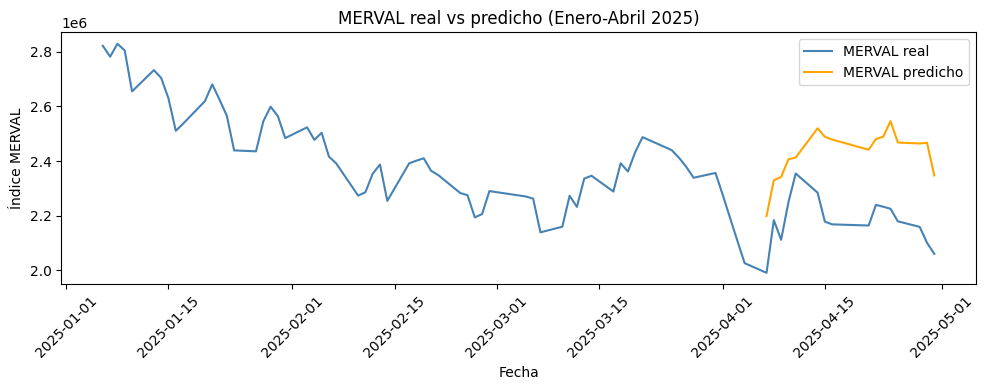

In [16]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (Enero-Abril 2025)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

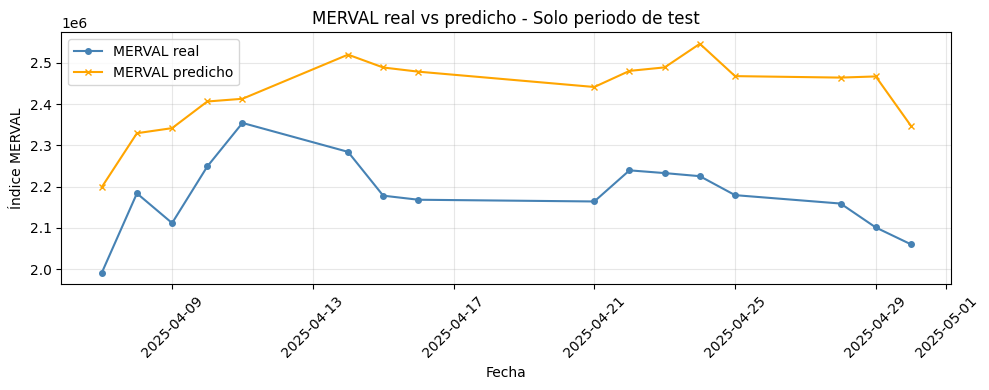

In [17]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Análisis de residuales

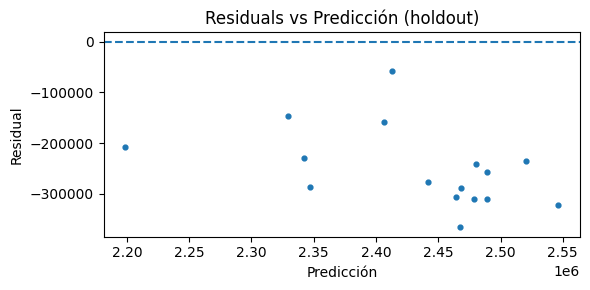

In [18]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


### 5.4. Importancia de variables

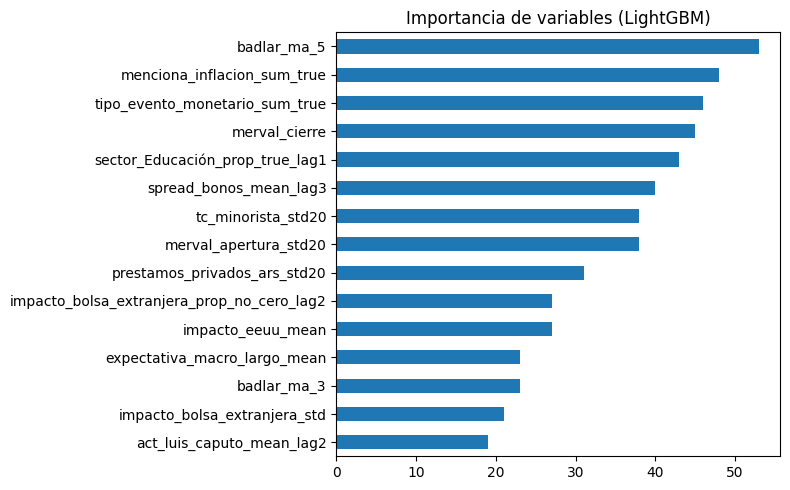

In [19]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()


## 6. Conclusiones

### Dataset con Features Generadas por LLM

Este modelo LightGBM fue entrenado utilizando un dataset alternativo que contiene **features generadas por un Large Language Model (LLM)** en lugar de las features tradicionales. El objetivo era evaluar si las features derivadas de LLM podrían mejorar la capacidad predictiva del modelo.

### Resultados principales

- **RMSE en test**: 261,329.34 - Error extremadamente alto que refleja el fracaso del modelo para generalizar con datos limitados.

- **R² en test**: -8.38 - El modelo tiene un desempeño catastrófico, mucho peor que simplemente predecir la media constante. Un R² de -8.38 significa que el modelo es aproximadamente 9.4 veces peor que el baseline más simple.

- **Error relativo**: 11.99% - Las predicciones se desvían en promedio casi 12% del valor real del MERVAL, lo cual es completamente inaceptable.

### Optimización de hiperparámetros

Se utilizó **Optuna** con 50 trials para encontrar la configuración óptima mediante validación cruzada temporal (TimeSeriesSplit con 3 folds).

**CV RMSE**: 114,907.73 - Error promedio en validación cruzada.

**Mejores hiperparámetros encontrados:**
- **learning_rate=0.066**: Tasa de aprendizaje moderada
- **num_leaves=12, max_depth=3**: Árboles muy simples para evitar overfitting
- **lambda_l1=1.29, lambda_l2=1.04**: Regularización moderada
- **min_child_samples=8, min_split_gain=0.86**: Restricciones conservadoras en splits
- **subsample=0.90, colsample_bytree=0.80**: Submuestreo alto
- **n_estimators=182**: Número moderado de árboles

### Análisis del problema: Dataset reducido con features LLM

**El dataset tiene 77 observaciones totales (61 train, 16 test)** y utiliza 60 features generadas por LLM.

**Discrepancia CV vs Test catastrófica**: El RMSE de validación cruzada (114,908) es menos de la mitad del RMSE de test (261,329), representando un incremento del **127%**. Esto indica:

1. **Overfitting severo**: A pesar de usar hiperparámetros extremadamente conservadores, el modelo memoriza ruido del conjunto de entrenamiento.

2. **Ratio features/observaciones crítico**: Con 60 features y 61 observaciones (ratio 1.02:1), el modelo está severamente subdeterminado.

3. **Validación cruzada engañosa**: Los folds de CV están altamente correlacionados y no representan el desempeño real en datos futuros.

### Comparación: Features tradicionales vs Features LLM

| Métrica | Dataset original (79 obs) | Dataset LLM (77 obs) | Diferencia |
|---------|---------------------------|----------------------|------------|
| Train size | 63 | 61 | -3% |
| Test RMSE | 285,651 | 261,329 | -9% (mejora leve) |
| Test R² | -10.21 | -8.38 | +18% (mejora leve) |
| CV RMSE | 133,972 | 114,908 | -14% (mejora leve) |
| Error relativo | 13.10% | 11.99% | -8% (mejora leve) |

**Observación**: El modelo con features LLM muestra una **mejora marginal** (~8-18% en métricas) comparado con features tradicionales, pero ambos modelos siguen siendo completamente inviables con R² fuertemente negativos.

### Análisis de las features generadas por LLM

Las features generadas por un LLM teóricamente podrían capturar relaciones más complejas o abstractas que las features tradicionales. Sin embargo:

1. **Mejora insuficiente**: Aunque hay mejora marginal (~8-18%), el modelo sigue siendo 9.4 veces peor que predecir la media constante.

2. **Validación imposible con pocos datos**: 61 observaciones no permiten determinar si las features LLM contienen señal genuina o ruido que casualmente correlaciona en entrenamiento.

3. **Riesgo de artefactos**: El modelo podría estar aprendiendo patrones específicos del proceso de generación LLM en lugar de relaciones económicas reales.

4. **Costo-beneficio cuestionable**: La mejora marginal no justifica el costo computacional de generar features con LLM.

### ¿Por qué falló LightGBM con features LLM?

A pesar de la optimización exhaustiva con Optuna y el uso de features supuestamente más sofisticadas:

1. **Problema fundamental de datos**: 61 observaciones son radicalmente insuficientes para 60 features, independientemente de su calidad o fuente.

2. **Overfitting inevitable**: Con ratio 1.02:1, el modelo no puede distinguir señal de ruido, incluso con regularización agresiva.

3. **Features LLM no son mágicas**: No pueden superar limitaciones matemáticas fundamentales de insuficiencia de datos.

4. **Gradient boosting requiere más datos**: LightGBM necesita típicamente cientos de observaciones para 60 features para funcionar correctamente.

### Limitaciones fundamentales

**LightGBM con features LLM no es viable para este problema debido a:**

1. **Insuficiencia crítica de datos**: 61 observaciones son incompatibles con 60 features para cualquier modelo de machine learning complejo.

2. **Overfitting severo irremediable**: El gap de 127% entre CV y Test RMSE demuestra que el modelo memoriza en lugar de aprender.

3. **Features LLM no compensan escasez de datos**: Aunque muestran mejora marginal, no pueden resolver el problema fundamental.

4. **Validación cruzada poco confiable**: Con datasets tan pequeños, el CV no refleja el verdadero error de generalización.

### Validación cruzada con dataset reducido

Se implementó TimeSeriesSplit muy conservador:
- **n_splits=3**: Tres folds de validación
- **test_size=8**: Ventana pequeña de validación
- **gap=5**: Separación para evitar leakage

Sin embargo, con datos tan limitados, incluso esta configuración conservadora no previene el overfitting catastrófico.

### Recomendaciones

**Para el dataset reducido con features LLM (77 observaciones):**

1. **No usar LightGBM con 60 features**: El modelo es fundamentalmente incompatible con este tamaño de datos.

2. **Reducir dimensionalidad drásticamente**:
   - Seleccionar solo 3-5 features LLM con mayor importancia
   - Mejorar ratio observaciones/features a niveles manejables (>10:1)
   - Evaluar si las features LLM seleccionadas realmente aportan sobre las tradicionales

3. **Modelos más simples**:
   - Regresión lineal (Ridge, Lasso) con pocas features
   - Modelos ARIMA univariados
   - Promedio móvil o métodos heurísticos

4. **Expandir el dataset**: Generar features LLM para el dataset completo (643 observaciones) y evaluar si el costo computacional se justifica con la mejora predictiva.

5. **Benchmark riguroso**: Con más datos, comparar modelos con y sin features LLM para cuantificar el valor real que aportan.

6. **Aceptar limitaciones**: Con 61 observaciones y 60 features, ningún modelo complejo (con o sin features LLM) puede ser confiable.

### Conclusión final

**El modelo LightGBM con features LLM fracasó completamente con el dataset reducido**. Un R² de -8.38 y un gap CV→Test de 127% confirman overfitting severo y total falta de generalización.

**Lecciones aprendidas:**

1. **Features LLM no son panacea**: Mejoraron marginalmente (~8-18%) pero no resolvieron el problema fundamental de escasez de datos.

2. **Cantidad > Sofisticación**: Con datasets pequeños, tener más observaciones es infinitamente más valioso que features sofisticadas.

3. **Validar con datos suficientes**: Para evaluar realmente si features LLM aportan valor, se necesita un dataset mucho más grande (>500 observaciones).

4. **Gradient boosting necesita datos abundantes**: LightGBM no es apropiado para datasets con menos de 10 observaciones por feature, independientemente de la calidad de las features.

5. **Costo-beneficio**: El costo computacional de generar features con LLM solo se justifica si hay suficientes datos para validar su utilidad real.